# Rossmann Store Sales: Preprocessing and EDA

This notebook has three parts. **Part A** describes and cleans the raw data, **Part B** explores it with visualizations and **Part C** creates the cleaned/preprocessed dataset that all four models (Seasonal Naive, Ridge, LightGBM, TFT) will use. 

And I made sure that the feature engineering and scaling parts are left for the modeling stage so that this way every model would train on the same base and nothing would leak.

# Part A: Data description and preparation

## A1. Loading the data and checking its structure

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
pd.set_option("display.max_columns",None)#for pandas no hidden cols
sns.set_theme(style='whitegrid')#for seaborn
#RAW=Path.cwd().parent
RAW=Path.cwd().parent / "data" / "raw"

In [3]:
# train loaded and Date parsed to column of real dates
train = pd.read_csv(RAW / "train.csv", parse_dates=['Date'],low_memory=False)
print(train.shape)

(1017209, 9)


In [4]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [5]:
# sales data date range (min and max)
print(train['Date'].min().date(), "to",train['Date'].max().date())

2013-01-01 to 2015-07-31


In [6]:
store = pd.read_csv(RAW / "store.csv") #store loaded
print(store.shape)

(1115, 10)


In [7]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017209 non-null  int64         
 1   DayOfWeek      1017209 non-null  int64         
 2   Date           1017209 non-null  datetime64[ns]
 3   Sales          1017209 non-null  int64         
 4   Customers      1017209 non-null  int64         
 5   Open           1017209 non-null  int64         
 6   Promo          1017209 non-null  int64         
 7   StateHoliday   1017209 non-null  object        
 8   SchoolHoliday  1017209 non-null  int64         
dtypes: datetime64[ns](1), int64(7), object(1)
memory usage: 69.8+ MB


In [9]:
store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


In [10]:
train["StateHoliday"].unique()# StateHoliday has 0 as well beside letter codes

array(['0', 'a', 'b', 'c'], dtype=object)

In [11]:
# to make sure no mix up will occur
train["StateHoliday"] = train["StateHoliday"].astype(str)
train["StateHoliday"].unique()

array(['0', 'a', 'b', 'c'], dtype=object)

## A2. Column dictionary, target and summary of statistics

Target variable: **Sales** (daily sales) for each store (continuous / regression forecasting)

In [12]:
train.describe()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1017209,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,2014-04-11 01:30:42.846061824,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
min,1.000000e+00,1.000000e+00,2013-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,2013-08-17 00:00:00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,2014-04-02 00:00:00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,2014-12-12 00:00:00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,2015-07-31 00:00:00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00
std,3.219087e+02,1.997391e+00,NaN,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01


In [13]:
store.describe()

,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1115.00000,1112.000000,761.000000,761.000000,1115.000000,571.000000,571.000000
mean,558.00000,5404.901079,7.224704,2008.668857,0.512108,23.595447,2011.763573
std,322.01708,7663.174720,3.212348,6.195983,0.500078,14.141984,1.674935
min,1.00000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,279.50000,717.500000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,558.00000,2325.000000,8.000000,2010.000000,1.000000,22.000000,2012.000000
75%,836.50000,6882.500000,10.000000,2013.000000,1.000000,37.000000,2013.000000
max,1115.00000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000


## A3. Integrity checks

additional checking for possible flaws

In [14]:
print(train.duplicated(["Store", "Date"]).sum()) # no Store Date row duplicate

0


In [15]:
print((train["Date"].dt.dayofweek +1 == train['DayOfWeek']).all())
# weekday column safe

True


In [16]:
print(train["Open"].unique())
print(train["Promo"].unique())
print(train["SchoolHoliday"].unique())
# all clean only 1 and 0

[1 0]
[1 0]
[1 0]


In [17]:
# clean min and max Sales vals
print(train['Sales'].min(),train['Sales'].max())

0 41551


In [18]:
# merging both files (store and train) is safe
print(set(train['Store'])==set(store["Store"]))

True


## A4. Missing Values and Merging

In [19]:
train.isna().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

In [20]:
# missing values are only in store detail columns in store.csv,
# so they should be handled before merging
store.isna().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [21]:
# 544 of the stores did not participated in promo2 at all
# so the 544 missings in promo2 detail columns is expected
print((store['Promo2']==0).sum())

544


In [22]:
# from the stores that didn't participate in promo2
# all of them are also missing Promo2SinceWeek
# this again shows the missing values are not random
print(store.loc[store["Promo2"] == 0, "Promo2SinceWeek"].isna().sum())

544


It isn't needed to keep the messy Promo2 detail columns (Promo2SinceWeek, Promo2SinceYear, PromoInterval) and only Promo2 column itself is enough for this project

Also, CompetitionOpenSinceMonth and CompetitionOpenSinceYear have too many missing vals (354) and they are not reliable enuogh or helpful

In [23]:
store_clean=store.copy()
store_clean = store_clean.drop(columns=["CompetitionOpenSinceMonth", "CompetitionOpenSinceYear","Promo2SinceWeek", "Promo2SinceYear", "PromoInterval"])

CompetitionDistance has only 3 missing values, therefore it is still a useful column and I will fill those few missings with the median competition dist

In [24]:
store_clean['CompetitionDistance'] = store_clean['CompetitionDistance'].fillna(store["CompetitionDistance"].median())

Now merging store and train (daily) data

In [25]:
df = train.merge(store_clean,on='Store', how="left")
print(df.shape) # now every daily sales row has extra store info added

(1017209, 13)


In [26]:
# no missing vals after merging
print(df.isna().sum().sum())

0


## A5. Closed days rows and Zero sales rows

When the store is closed (Open=0) it is expected to have 0 Sales

In [27]:
# making sure all close days have 0 Sales as expected
print(df['Open'].value_counts())
print(((df['Open']==0) & (df["Sales"]==0)).sum())#closed no sales (correctly all)
print(((df['Open']==0) & (df["Sales"]>0)).sum())# closed with sales (correctly 0)

Open
1    844392
0    172817
Name: count, dtype: int64
172817
0


One thing that would be very likely error if it exists is if there are cases that Open = 1 but Sales = 0 and Customers = 0 because that is very unusual

In [28]:
print(((df['Open']==1) & (df["Sales"]==0)).sum())
# I will drop because they are few and not useful for learning/training
# they are not normal sales behaviour
df = df[~((df['Open']==1) & (df["Sales"]==0))]
print(((df['Open']==1) & (df["Sales"]==0)).sum())
print("kept rows", len(df))

54
0
kept rows 1017155


In [29]:
#creating open_df for eda part (part B)
open_df = df[df['Open']==1]
print(len(open_df))#open day rows for eda

844338


## A6. Date continuity per store

Making sure each store has a row for each day (no missing dates / gaps)

In [30]:
#each store's date row counts
days_per_store = train.groupby("Store")['Date'].count()

In [31]:
# total days count
print((train['Date'].max()-train['Date'].min()).days+1)
#print((train['Date'].max()-train['Date'].min()).days)

942


In [32]:
# 934 stores correctly have all 942 days
# 181 stores have missing dates (one of them just missing 1 date)
print(days_per_store.value_counts())

Date
942    934
758    180
941      1
Name: count, dtype: int64


In [33]:
# one store that has missing date as example to see missing dates of it
short_store = days_per_store[days_per_store==758].index[0]
one = train[train["Store"]==short_store]
#print(short_store)
#print(len(one))
fullRange = pd.date_range(one['Date'].min(),one['Date'].max())
gap = fullRange.difference(one['Date'])
print(gap.min().date(), gap.max().date())#missing portion/range

2014-07-01 2014-12-31


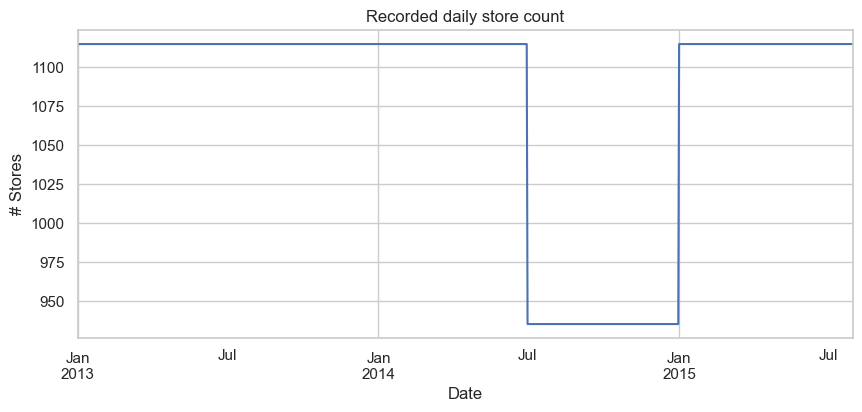

In [34]:
plt.figure(figsize=(10,4))
train.groupby('Date').size().plot()
plt.title("Recorded daily store count")
plt.ylabel("# Stores")
plt.show()

Number of stores that are recorded for each day are mostly stable, the only thing is that there is a drop from July until December 2014 (many stores have missing date rows during that time)

Issue fixed in part C